In [ ]:
import os, json, random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
import tensorflow as tf

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

# -------------------------
# Config
# -------------------------
SEED = 42
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

HEAD_EPOCHS     = 15
FINE_TUNE_EPOCHS = 8
HEAD_LR         = 1e-3
FINE_TUNE_LR    = 1e-5
FINE_TUNE_LAYERS = 30

USE_ONLINE_AUGMENTATION = True

# Model 1 mapping
NORMAL_CLASS_NAMES = ["Normal"]
ANOMALY_CLASS_NAMES = [
    "Diabetic Retinopathy", "Glaucoma", "Cataract",
    "AMD", "Hypertension", "Myopia", "Others"
]

print("Config loaded.")
print("Normal  :", NORMAL_CLASS_NAMES)
print("Anomaly :", ANOMALY_CLASS_NAMES)

Config loaded.
Normal  : ['Normal']
Anomaly : ['Diabetic Retinopathy', 'Glaucoma', 'Cataract', 'AMD', 'Hypertension', 'Myopia', 'Others']


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

DATA_ROOT = Path("/content/drive/MyDrive/Cellula/EyeDisease/Data")

IMAGES_DIR    = DATA_ROOT / "images"
METADATA_PATH = DATA_ROOT / "metadata.csv"
AUGMENTED_DIR = DATA_ROOT / "images_augmented_v2"
SPLIT_DIR     = DATA_ROOT / "dataset_splits_v2"

TRAIN_DIR = SPLIT_DIR / "train"
VAL_DIR   = SPLIT_DIR / "val"
TEST_DIR  = SPLIT_DIR / "test"

MODEL_DIR   = DATA_ROOT.parent / "models"
RESULTS_DIR = DATA_ROOT / "model1_results"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

for name, p in [("DATA_ROOT", DATA_ROOT), ("TRAIN_DIR", TRAIN_DIR),
                ("VAL_DIR", VAL_DIR), ("TEST_DIR", TEST_DIR)]:
    print(f"{name:<12} {p}  exists={p.exists()}")

for p in [DATA_ROOT, TRAIN_DIR, VAL_DIR, TEST_DIR]:
    if not p.exists():
        raise FileNotFoundError(f"Missing: {p}")

Mounted at /content/drive
DATA_ROOT    /content/drive/MyDrive/Cellula/EyeDisease/Data  exists=True
TRAIN_DIR    /content/drive/MyDrive/Cellula/EyeDisease/Data/dataset_splits_v2/train  exists=True
VAL_DIR      /content/drive/MyDrive/Cellula/EyeDisease/Data/dataset_splits_v2/val  exists=True
TEST_DIR     /content/drive/MyDrive/Cellula/EyeDisease/Data/dataset_splits_v2/test  exists=True


In [ ]:
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

gpus = tf.config.list_physical_devices("GPU")
if gpus:
    try:
        for g in gpus:
            tf.config.experimental.set_memory_growth(g, True)
    except Exception as e:
        print("Memory growth note:", e)

print("TF:", tf.__version__)
print("GPUs:", gpus)

TF: 2.20.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
VALID_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

def get_subdirectories(path):
    return sorted([p for p in Path(path).iterdir() if p.is_dir()],
                  key=lambda x: x.name.lower())

def get_image_files(path):
    return [p for p in Path(path).rglob("*")
            if p.is_file() and p.suffix.lower() in VALID_EXT]

def normalize_class_name(name):
    return name.lower().replace("_", " ").replace("-", " ").strip()

def find_matching_folder(expected_name, folder_dict):
    exp = normalize_class_name(expected_name)
    matches = [p for n, p in folder_dict.items()
               if normalize_class_name(n) == exp]
    if len(matches) == 1:
        return matches[0]
    if len(matches) > 1:
        raise RuntimeError(f"Multiple matches for '{expected_name}': {matches}")
    return None

In [ ]:
train_folders = {p.name: p for p in get_subdirectories(TRAIN_DIR)}
val_folders   = {p.name: p for p in get_subdirectories(VAL_DIR)}
test_folders  = {p.name: p for p in get_subdirectories(TEST_DIR)}

print("Train folders:", list(train_folders.keys()))
print("Val folders  :", list(val_folders.keys()))
print("Test folders :", list(test_folders.keys()))

Train folders: ['AMD', 'Cataract', 'Diabetic Retinopathy', 'Glaucoma', 'Hypertension', 'Myopia', 'Normal', 'Others']
Val folders  : ['AMD', 'Cataract', 'Diabetic Retinopathy', 'Glaucoma', 'Hypertension', 'Myopia', 'Normal', 'Others']
Test folders : ['AMD', 'Cataract', 'Diabetic Retinopathy', 'Glaucoma', 'Hypertension', 'Myopia', 'Normal', 'Others']


In [ ]:
ALL_ORIGINAL = ["Normal"] + ANOMALY_CLASS_NAMES

class_folder_map = {"train": {}, "val": {}, "test": {}}
for split, folders in [("train", train_folders),
                       ("val",   val_folders),
                       ("test",  test_folders)]:
    for cname in ALL_ORIGINAL:
        m = find_matching_folder(cname, folders)
        class_folder_map[split][cname] = m  # may be None

# Per-class counts
rows = {}
for split in ["train", "val", "test"]:
    rows[split] = {}
    for cname in ALL_ORIGINAL:
        f = class_folder_map[split][cname]
        rows[split][cname] = len(get_image_files(f)) if f is not None else 0

orig_counts_df = pd.DataFrame(rows)
print("Original per-class counts:")
display(orig_counts_df)

# Binary counts
def binary_counts(split):
    normal  = orig_counts_df.loc["Normal", split]
    anomaly = orig_counts_df.drop(index="Normal")[split].sum()
    return normal, anomaly

print("\nBinary counts (Model 1):")
for split in ["train", "val", "test"]:
    n, a = binary_counts(split)
    print(f"  {split:<5}  Normal={n:<6}  Anomaly={a:<6}  Total={n+a}")

Original per-class counts:


,train,val,test
Normal,3000,705,705
Diabetic Retinopathy,2800,617,617
Glaucoma,1500,139,140
Cataract,1000,51,51
AMD,1000,41,41
Hypertension,500,13,13
Myopia,1000,44,44
Others,1500,166,165



Binary counts (Model 1):
  train  Normal=3000    Anomaly=9300    Total=12300
  val    Normal=705     Anomaly=1071    Total=1776
  test   Normal=705     Anomaly=1071    Total=1776


In [ ]:
issues = []

# Missing folders
for split in ["train", "val", "test"]:
    for cname in ALL_ORIGINAL:
        if class_folder_map[split][cname] is None:
            issues.append(f"[MISSING] '{cname}' in {split}")

# Empty folders
for split in ["train", "val", "test"]:
    for cname in ALL_ORIGINAL:
        f = class_folder_map[split][cname]
        if f is not None and len(get_image_files(f)) == 0:
            issues.append(f"[EMPTY] '{cname}' in {split}")

# Corrupted check
corrupted = []
for split, split_dir in [("train", TRAIN_DIR), ("val", VAL_DIR), ("test", TEST_DIR)]:
    for f in get_image_files(split_dir):
        try:
            with Image.open(f) as im:
                im.verify()
        except Exception:
            corrupted.append(str(f))

print("Structural issues:", len(issues))
for i in issues[:20]:
    print("  ", i)

print("\nCorrupted images:", len(corrupted))
for c in corrupted[:10]:
    print("  ", c)

KeyboardInterrupt: 

In [ ]:
def collect_names(split_dir):
    return set(p.name for p in get_image_files(split_dir))

train_names = collect_names(TRAIN_DIR)
val_names   = collect_names(VAL_DIR)
test_names  = collect_names(TEST_DIR)

print("Filename overlap:")
print("  Train ∩ Val :", len(train_names & val_names))
print("  Train ∩ Test:", len(train_names & test_names))
print("  Val   ∩ Test:", len(val_names & test_names))

AUG_KEYWORDS = ["aug", "augment", "flip", "rot", "rotate",
                "zoom", "shift", "brightness", "contrast"]

def looks_augmented(name):
    n = name.lower()
    return any(k in n for k in AUG_KEYWORDS)

val_aug  = [f for f in get_image_files(VAL_DIR)  if looks_augmented(f.name)]
test_aug = [f for f in get_image_files(TEST_DIR) if looks_augmented(f.name)]

print("\nAugmentation-like filenames:")
print("  Val :", len(val_aug))
print("  Test:", len(test_aug))

if val_aug or test_aug:
    print("\n⚠️ WARNING: possible augmentation leakage in val/test.")
    for f in (val_aug + test_aug)[:10]:
        print("   ", f)
else:
    print("No augmentation leakage detected in val/test.")

Filename overlap:
  Train ∩ Val : 0
  Train ∩ Test: 0
  Val   ∩ Test: 0

Augmentation-like filenames:
  Val : 0
  Test: 0
No augmentation leakage detected in val/test.


In [ ]:
def build_binary_lists(split):
    """Returns (paths, labels) with 0=Normal, 1=Anomaly."""
    paths, labels = [], []

    # Normal
    nfolder = class_folder_map[split]["Normal"]
    if nfolder is not None:
        for p in get_image_files(nfolder):
            paths.append(str(p)); labels.append(0)

    # Anomaly (all others)
    for cname in ANOMALY_CLASS_NAMES:
        f = class_folder_map[split][cname]
        if f is not None:
            for p in get_image_files(f):
                paths.append(str(p)); labels.append(1)

    return paths, labels

train_paths, train_labels = build_binary_lists("train")
val_paths,   val_labels   = build_binary_lists("val")
test_paths,  test_labels  = build_binary_lists("test")

print(f"Train: {len(train_paths)}  (Normal={train_labels.count(0)}, Anomaly={train_labels.count(1)})")
print(f"Val  : {len(val_paths)}    (Normal={val_labels.count(0)}, Anomaly={val_labels.count(1)})")
print(f"Test : {len(test_paths)}   (Normal={test_labels.count(0)}, Anomaly={test_labels.count(1)})")

Train: 12300  (Normal=3000, Anomaly=9300)
Val  : 1776    (Normal=705, Anomaly=1071)
Test : 1776   (Normal=705, Anomaly=1071)


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32)
    return img, label

def make_ds(paths, labels, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices(
        (tf.constant(paths), tf.constant(labels, dtype=tf.int32)))
    if shuffle:
        ds = ds.shuffle(min(len(paths), 2000), seed=SEED)
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)
    return ds

train_ds = make_ds(train_paths, train_labels, shuffle=True)
val_ds   = make_ds(val_paths,   val_labels,   shuffle=False)
test_ds  = make_ds(test_paths,  test_labels,  shuffle=False)

imgs, lbls = next(iter(train_ds))
print("Batch:", imgs.shape, lbls.shape,
      "range:", float(tf.reduce_min(imgs)), "-", float(tf.reduce_max(imgs)))

Batch: (32, 224, 224, 3) (32,) range: 0.0 - 255.0


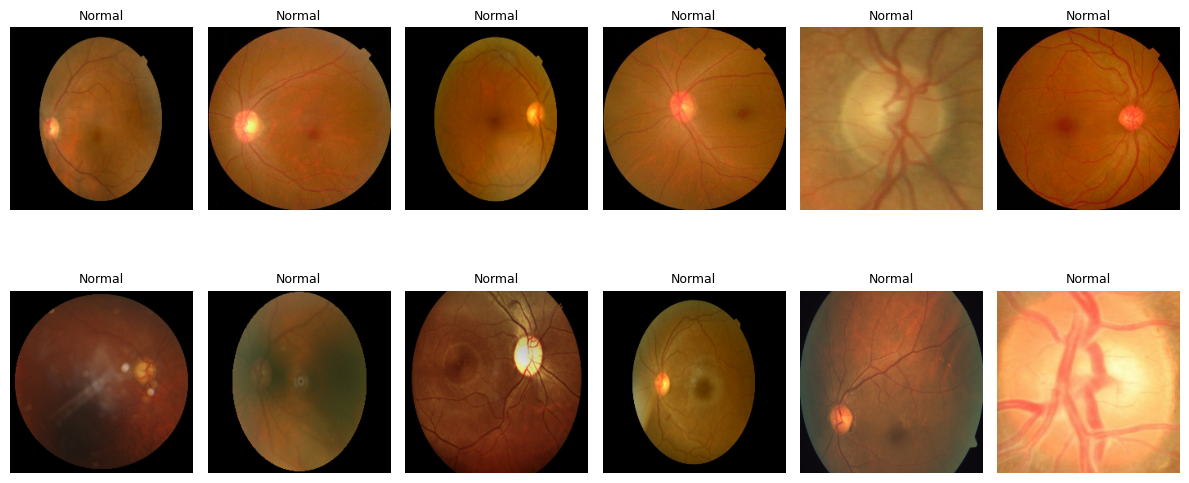

In [ ]:
plt.figure(figsize=(12, 6))
for i in range(min(12, len(imgs))):
    plt.subplot(2, 6, i+1)
    plt.imshow(imgs[i].numpy().astype("uint8"))
    plt.title("Normal" if int(lbls[i]) == 0 else "Anomaly", fontsize=9)
    plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
train_labels_arr = np.array(train_labels)

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=train_labels_arr
)
class_weights = {0: float(weights[0]), 1: float(weights[1])}

print("Binary class weights:")
print(f"  Normal  (0): count={train_labels.count(0)}  weight={class_weights[0]:.4f}")
print(f"  Anomaly (1): count={train_labels.count(1)}  weight={class_weights[1]:.4f}")

with open(RESULTS_DIR / "class_weights.json", "w") as f:
    json.dump({"Normal": class_weights[0], "Anomaly": class_weights[1]}, f, indent=4)

Binary class weights:
  Normal  (0): count=3000  weight=2.0500
  Anomaly (1): count=9300  weight=0.6613


In [ ]:
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

# Online augmentation (training only — applied in .map stage below)
if USE_ONLINE_AUGMENTATION:
    aug_layer = tf.keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.03),
        layers.RandomZoom(0.08, 0.08),
        layers.RandomTranslation(0.03, 0.03),
        layers.RandomBrightness(0.08),
        layers.RandomContrast(0.08),
    ], name="augmentation")
else:
    aug_layer = None

inputs = layers.Input(shape=(*IMG_SIZE, 3), name="input_image")
x = aug_layer(inputs) if aug_layer is not None else inputs
x = preprocess_input(x)

base_model = ResNet50(
    include_top=False, weights="imagenet",
    input_shape=(*IMG_SIZE, 3), name="resnet50"
)
base_model.trainable = False

x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D(name="gap")(x)
x = layers.Dropout(0.40, name="dropout_1")(x)
x = layers.Dense(128, activation="relu", name="dense_128")(x)
x = layers.Dropout(0.30, name="dropout_2")(x)
outputs = layers.Dense(1, activation="sigmoid", name="classifier")(x)

model = Model(inputs, outputs, name="Model1_ResNet50_NormalVsAnomaly")
model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "Model1_ResNet50_NormalVsAnomaly"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ augmentation        │ (None, 224, 224,  │          0 │ input_image[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ augmentation[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ augmentation[0][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ augmentation[0][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gap                 │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 2048)      │          0 │ gap[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_128 (Dense)   │ (None, 128)       │    262,272 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ dense_128[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ classifier (Dense)  │ (None, 1)         │        129 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(HEAD_LR),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
    ]
)
print("Stage 1 compiled.")

Stage 1 compiled.


In [ ]:
STAGE1_BEST = MODEL_DIR / "model1_resnet50_stage1_best.keras"

callbacks_s1 = [
    tf.keras.callbacks.ModelCheckpoint(
        str(STAGE1_BEST), monitor="val_loss",
        save_best_only=True, verbose=1),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=5,
        restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5,
        patience=2, min_lr=1e-6, verbose=1),
]

print("=" * 60); print("STAGE 1 — Frozen ResNet50"); print("=" * 60)

history_s1 = model.fit(
    train_ds, validation_data=val_ds,
    epochs=HEAD_EPOCHS, class_weight=class_weights,
    callbacks=callbacks_s1, verbose=1
)

stage1_best_val_loss = float(min(history_s1.history["val_loss"]))
print("Stage 1 best val_loss:", stage1_best_val_loss)

STAGE 1 — Frozen ResNet50
Epoch 1/15
385/385 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8315 - loss: 0.4100 - precision: 0.7846 - recall: 0.5162
Epoch 1: val_loss improved from None to 1.38653, saving model to /content/drive/MyDrive/Cellula/EyeDisease/models/model1_resnet50_stage1_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Cellula/EyeDisease/models/model1_resnet50_stage1_best.keras
385/385 ━━━━━━━━━━━━━━━━━━━━ 2116s 5s/step - accuracy: 0.8673 - loss: 0.3302 - precision: 0.9586 - recall: 0.8617 - val_accuracy: 0.6222 - val_loss: 1.3865 - val_precision: 0.6157 - val_recall: 0.9935 - learning_rate: 0.0010
Epoch 2/15
385/385 ━━━━━━━━━━━━━━━━━━━━ 0s 572ms/step - accuracy: 0.8155 - loss: 0.5723 - precision: 0.7145 - recall: 0.5550
Epoch 2: val_loss did not improve from 1.38653
385/385 ━━━━━━━━━━━━━━━━━━━━ 249s 646ms/step - accuracy: 0.8713 - loss: 0.3644 - precision: 0.9500 - recall: 0.8759 - val_accuracy: 0.6042 - val_loss: 1.4243 - val_precision: 0.6037 - val_r

In [ ]:
# Load best Stage 1
model = tf.keras.models.load_model(STAGE1_BEST)

base_model = model.get_layer("resnet50")
base_model.trainable = True

total_layers = len(base_model.layers)
freeze_until = max(0, total_layers - FINE_TUNE_LAYERS)

for i, layer in enumerate(base_model.layers):
    if i < freeze_until:
        layer.trainable = False
    else:
        layer.trainable = not isinstance(layer, tf.keras.layers.BatchNormalization)

print(f"Trainable backbone layers: {sum(1 for l in base_model.layers if l.trainable)} / {total_layers}")

model.compile(
    optimizer=tf.keras.optimizers.Adam(FINE_TUNE_LR),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
    ]
)
print("Stage 2 compiled.")

Trainable backbone layers: 21 / 175
Stage 2 compiled.


In [ ]:
STAGE2_BEST = MODEL_DIR / "model1_resnet50_stage2_best.keras"

callbacks_s2 = [
    tf.keras.callbacks.ModelCheckpoint(
        str(STAGE2_BEST), monitor="val_loss",
        save_best_only=True, verbose=1),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=3,
        restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5,
        patience=1, min_lr=1e-7, verbose=1),
]

print("=" * 60); print("STAGE 2 — Fine-tuning"); print("=" * 60)

history_s2 = model.fit(
    train_ds, validation_data=val_ds,
    epochs=FINE_TUNE_EPOCHS, class_weight=class_weights,
    callbacks=callbacks_s2, verbose=1
)

stage2_best_val_loss = float(min(history_s2.history["val_loss"]))
print("Stage 2 best val_loss:", stage2_best_val_loss)

STAGE 2 — Fine-tuning
Epoch 1/8
385/385 ━━━━━━━━━━━━━━━━━━━━ 0s 567ms/step - accuracy: 0.7983 - loss: 0.6060 - precision: 0.6990 - recall: 0.6013
Epoch 1: val_loss improved from None to 1.50566, saving model to /content/drive/MyDrive/Cellula/EyeDisease/models/model1_resnet50_stage2_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Cellula/EyeDisease/models/model1_resnet50_stage2_best.keras
385/385 ━━━━━━━━━━━━━━━━━━━━ 262s 653ms/step - accuracy: 0.8761 - loss: 0.3435 - precision: 0.9426 - recall: 0.8903 - val_accuracy: 0.6160 - val_loss: 1.5057 - val_precision: 0.6110 - val_recall: 1.0000 - learning_rate: 1.0000e-05
Epoch 2/8
385/385 ━━━━━━━━━━━━━━━━━━━━ 0s 573ms/step - accuracy: 0.7604 - loss: 0.7339 - precision: 0.6693 - recall: 0.5448
Epoch 2: val_loss improved from 1.50566 to 1.22989, saving model to /content/drive/MyDrive/Cellula/EyeDisease/models/model1_resnet50_stage2_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Cellula/EyeDisease/model

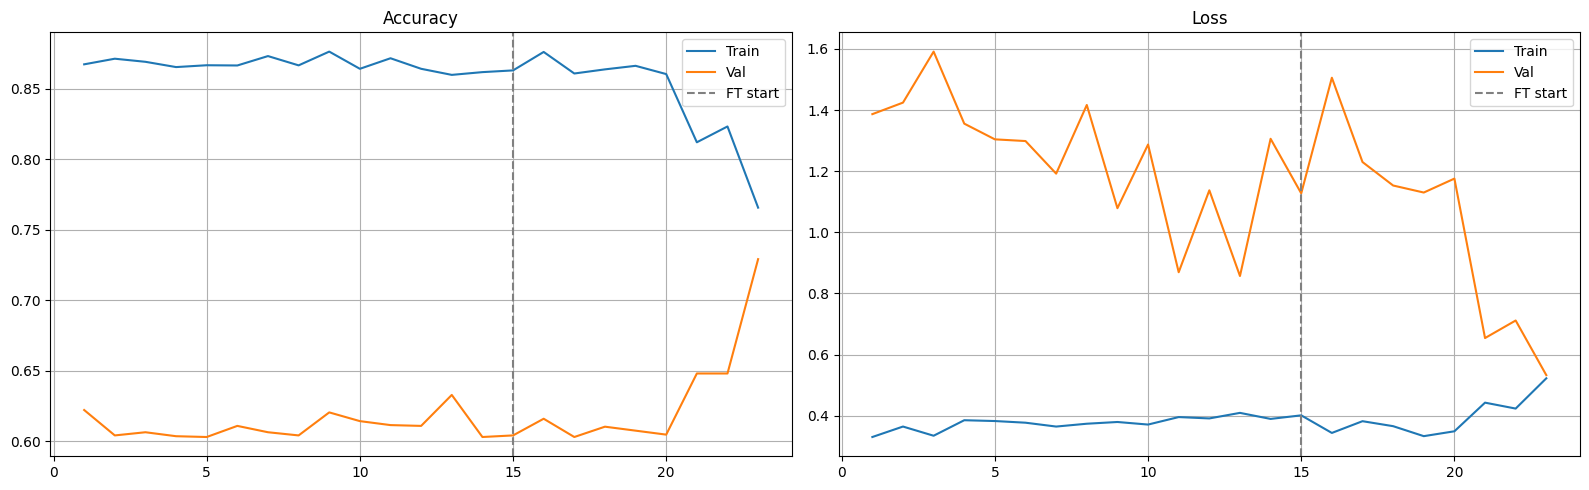

In [ ]:
history_combined = {}
for k in history_s1.history:
    history_combined[k] = history_s1.history[k] + history_s2.history.get(k, [])

with open(RESULTS_DIR / "history.json", "w") as f:
    json.dump({k: [float(v) for v in vals] for k, vals in history_combined.items()},
              f, indent=4)

df = pd.DataFrame(history_combined)
epochs_range = range(1, len(df)+1)
stage1_end = len(history_s1.history["loss"])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(epochs_range, df["accuracy"], label="Train")
axes[0].plot(epochs_range, df["val_accuracy"], label="Val")
axes[0].axvline(stage1_end, ls="--", color="gray", label="FT start")
axes[0].set_title("Accuracy"); axes[0].legend(); axes[0].grid(True)

axes[1].plot(epochs_range, df["loss"], label="Train")
axes[1].plot(epochs_range, df["val_loss"], label="Val")
axes[1].axvline(stage1_end, ls="--", color="gray", label="FT start")
axes[1].set_title("Loss"); axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
if stage2_best_val_loss < stage1_best_val_loss:
    best_stage = "Stage 2"
    best_source = STAGE2_BEST
    best_val_loss = stage2_best_val_loss
else:
    best_stage = "Stage 1"
    best_source = STAGE1_BEST
    best_val_loss = stage1_best_val_loss

FINAL_BEST = MODEL_DIR / "model1_resnet50_normal_vs_anomaly_best.keras"

# reload & save as final
best_model = tf.keras.models.load_model(best_source)
best_model.save(FINAL_BEST)

print(f"Selected: {best_stage}")
print(f"Best val_loss: {best_val_loss:.6f}")
print(f"Final model saved: {FINAL_BEST}")

Selected: Stage 2
Best val_loss: 0.532634
Final model saved: /content/drive/MyDrive/Cellula/EyeDisease/models/model1_resnet50_normal_vs_anomaly_best.keras


In [ ]:
best_model = tf.keras.models.load_model(FINAL_BEST)

y_true, y_prob = [], []

for bx, by in test_ds:
    p = best_model(bx, training=False).numpy().ravel()
    y_prob.extend(p.tolist())
    y_true.extend(by.numpy().tolist())

y_true = np.array(y_true, dtype=np.int32)
y_prob = np.array(y_prob, dtype=np.float32)
y_pred = (y_prob >= 0.5).astype(np.int32)

print("Test samples:", len(y_true))
print("Normal in test:", int((y_true == 0).sum()),
      "| Anomaly in test:", int((y_true == 1).sum()))

Test samples: 1776
Normal in test: 705 | Anomaly in test: 1071


In [ ]:
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, zero_division=0)
rec  = recall_score(y_true, y_pred, zero_division=0)
f1   = f1_score(y_true, y_pred, zero_division=0)

macro_p  = precision_score(y_true, y_pred, average="macro",    zero_division=0)
macro_r  = recall_score   (y_true, y_pred, average="macro",    zero_division=0)
macro_f1 = f1_score       (y_true, y_pred, average="macro",    zero_division=0)
w_p      = precision_score(y_true, y_pred, average="weighted", zero_division=0)
w_r      = recall_score   (y_true, y_pred, average="weighted", zero_division=0)
w_f1     = f1_score       (y_true, y_pred, average="weighted", zero_division=0)

print("=" * 60)
print("MODEL 1 — TEST METRICS")
print("=" * 60)
print(f"Accuracy            : {acc:.4f}")
print(f"Anomaly Precision   : {prec:.4f}")
print(f"Anomaly Recall      : {rec:.4f}")
print(f"Anomaly F1          : {f1:.4f}")
print(f"Macro  P / R / F1   : {macro_p:.4f} / {macro_r:.4f} / {macro_f1:.4f}")
print(f"Weight P / R / F1   : {w_p:.4f} / {w_r:.4f} / {w_f1:.4f}")

report_dict = classification_report(
    y_true, y_pred, labels=[0, 1],
    target_names=["Normal", "Anomaly"],
    output_dict=True, zero_division=0
)
report_df = pd.DataFrame(report_dict).transpose()
display(report_df)
report_df.to_csv(RESULTS_DIR / "classification_report.csv")

MODEL 1 — TEST METRICS
Accuracy            : 0.7241
Anomaly Precision   : 0.6964
Anomaly Recall      : 0.9617
Anomaly F1          : 0.8078
Macro  P / R / F1   : 0.7792 / 0.6624 / 0.6594
Weight P / R / F1   : 0.7621 / 0.7241 / 0.6900


,precision,recall,f1-score,support
Normal,0.861953,0.363121,0.510978,705.000000
Anomaly,0.696416,0.961718,0.807843,1071.000000
accuracy,0.724099,0.724099,0.724099,0.724099
macro avg,0.779185,0.662419,0.659411,1776.000000
weighted avg,0.762128,0.724099,0.690000,1776.000000


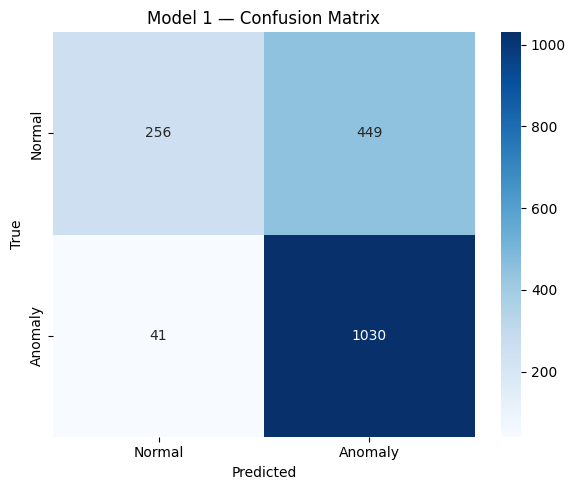

Anomaly Recall = 0.9617


In [ ]:
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal", "Anomaly"],
            yticklabels=["Normal", "Anomaly"])
plt.title("Model 1 — Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

pd.DataFrame(cm, index=["Normal","Anomaly"], columns=["Normal","Anomaly"])\
  .to_csv(RESULTS_DIR / "confusion_matrix.csv")

print("Anomaly Recall =", f"{rec:.4f}")